# 实验5：IMDB 影评情感分类

本实验使用 IMDB-Dataset.csv 完成影评正负情感二分类。整体流程是先做文本清洗和序列化，再用 LSTM 读取一整段影评，最后输出一个情感类别。

## 实验要求摘要和导入库

根据 `实验5－题目.docx` 整理的任务要求是：使用 IMDB 数据集，按 80%/10%/10% 划分训练集、验证集和测试集，序列长度统一为 maxlen=200，并使用 LSTM/GRU 与 EarlyStopping 完成分类。这里导入脚本中已经写好的函数，避免 notebook 变成一个很长的大代码块。

In [3]:
from pathlib import Path

import pandas as pd
import torch
from IPython.display import Image, display

from exp5_imdb_lstm import (
    DATA_PATH, OUTPUT_DIR, BEST_MODEL_PATH,
    RANDOM_SEED, MAX_LEN, MAX_VOCAB_SIZE, MIN_WORD_FREQ,
    BATCH_SIZE, NUM_EPOCHS, LEARNING_RATE, PATIENCE,
    EMBED_DIM, HIDDEN_SIZE, NUM_LAYERS, DROPOUT, BIDIRECTIONAL,
    LABEL_TO_ID, ID_TO_LABEL,
    set_seed, get_device, clean_text, tokenize, build_vocab,
    IMDBReviewDataset, make_loader, LSTMSentimentClassifier,
    train_test_split, nn, train_model, collect_predictions,
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
    plot_label_distribution, plot_length_distribution, plot_training_loss,
    plot_accuracy_curve, plot_confusion_matrix, plot_metrics_bar,
    predict_review, save_prediction_examples, save_wrong_examples,
)

set_seed(RANDOM_SEED)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
device = get_device()
print("当前设备:", device)
if torch.cuda.is_available():
    print("CUDA:", torch.cuda.get_device_name(0))

当前设备: cuda
CUDA: NVIDIA GeForce RTX 4090


## 参数设置

这些参数和 py 脚本保持一致。maxlen 控制每条影评最终保留或填充到 200 个 token，batch_size 和 epoch 数参考题目要求设置。

In [4]:
params = {
    "MAX_LEN": MAX_LEN,
    "MAX_VOCAB_SIZE": MAX_VOCAB_SIZE,
    "MIN_WORD_FREQ": MIN_WORD_FREQ,
    "BATCH_SIZE": BATCH_SIZE,
    "NUM_EPOCHS": NUM_EPOCHS,
    "LEARNING_RATE": LEARNING_RATE,
    "PATIENCE": PATIENCE,
    "EMBED_DIM": EMBED_DIM,
    "HIDDEN_SIZE": HIDDEN_SIZE,
    "BIDIRECTIONAL": BIDIRECTIONAL,
}
params

{'MAX_LEN': 200,
 'MAX_VOCAB_SIZE': 20000,
 'MIN_WORD_FREQ': 2,
 'BATCH_SIZE': 64,
 'NUM_EPOCHS': 8,
 'LEARNING_RATE': 0.001,
 'PATIENCE': 2,
 'EMBED_DIM': 128,
 'HIDDEN_SIZE': 128,
 'BIDIRECTIONAL': True}

## 读取数据集

读取 IMDB-Dataset.csv 后，把 positive/negative 映射成 1/0。先看样本数量和标签分布，确认数据集是均衡的。

数据集路径: C:\Users\qintian\Desktop\人工智能\实验五\IMDB-Dataset.csv
数据总量: 50000
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


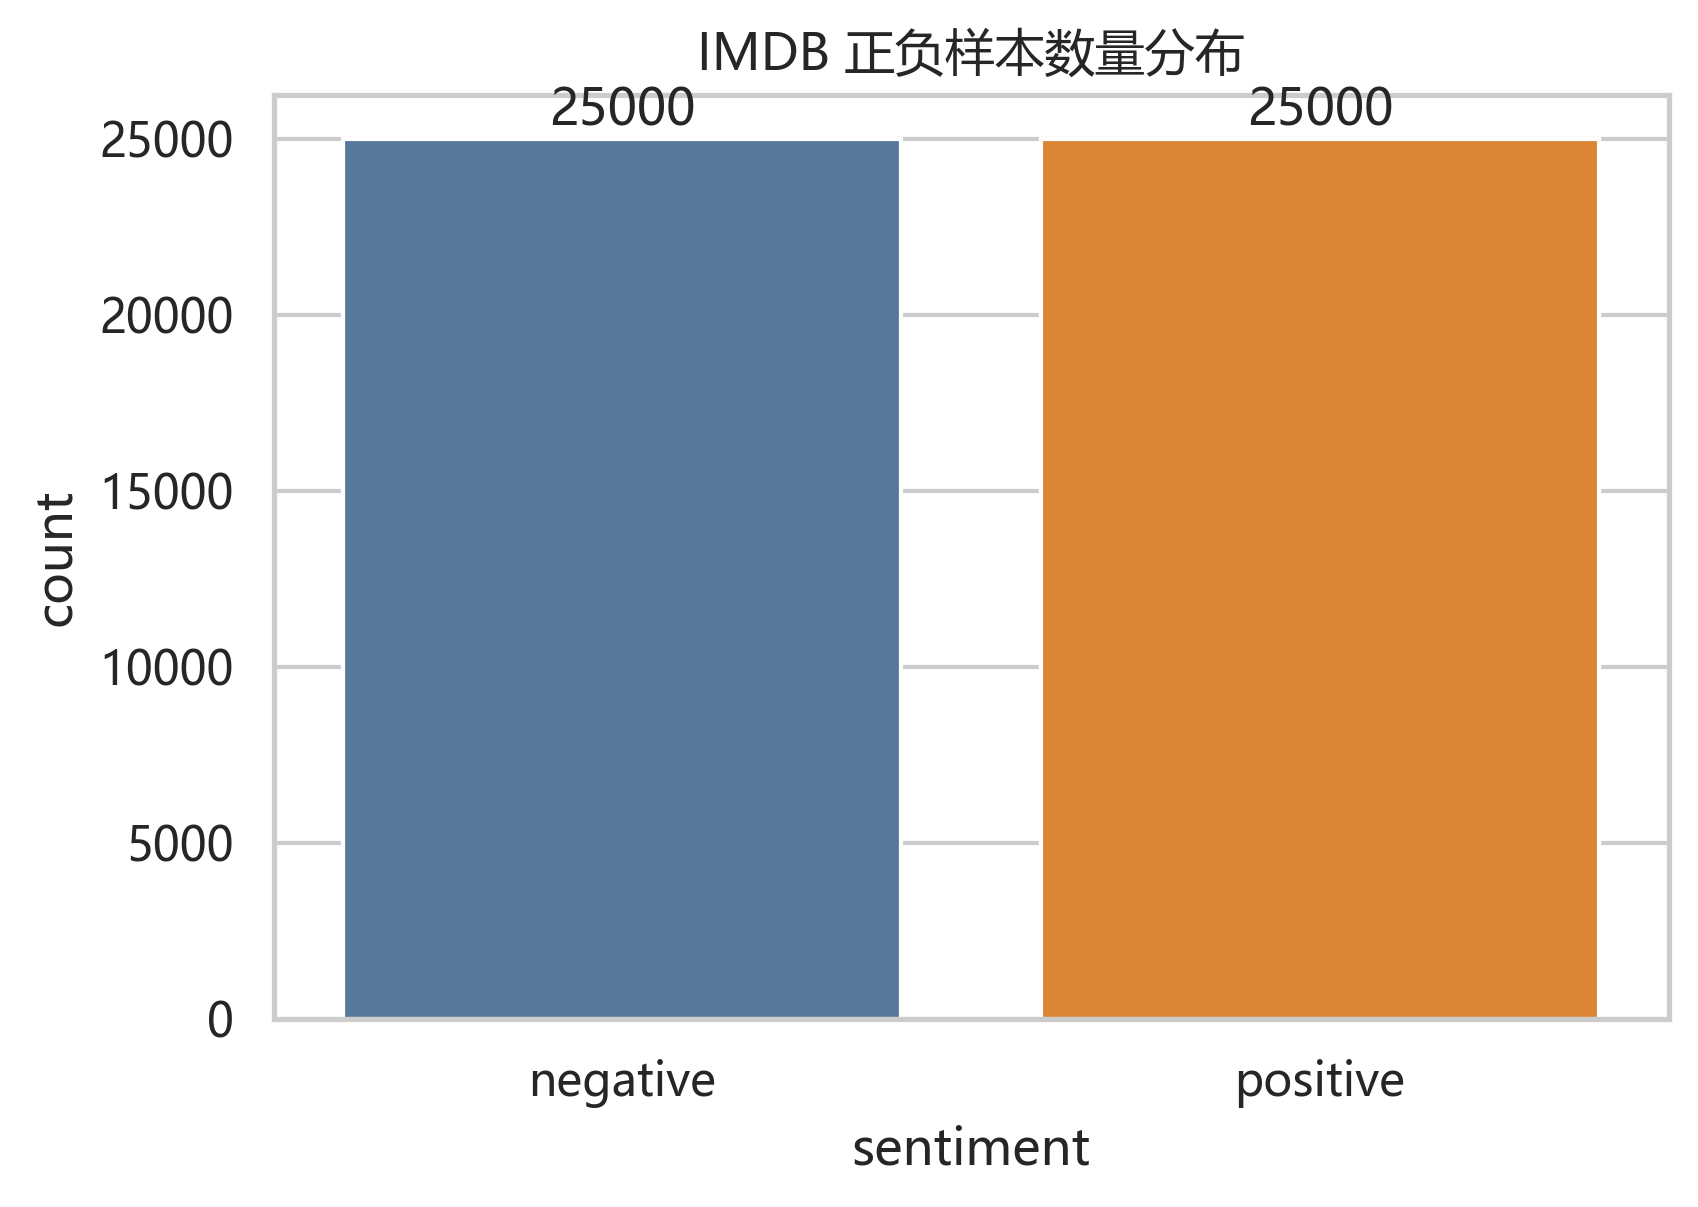

In [5]:
df = pd.read_csv(DATA_PATH).dropna(subset=["review", "sentiment"]).copy()
df["label"] = df["sentiment"].map(LABEL_TO_ID).astype(int)
print("数据集路径:", DATA_PATH)
print("数据总量:", len(df))
print(df["sentiment"].value_counts())

plot_label_distribution(df, OUTPUT_DIR / "exp5_label_distribution.png")
display(Image(filename=str(OUTPUT_DIR / "exp5_label_distribution.png")))

## 文本清洗和预处理

影评里有 `<br />` 这样的 HTML 标签，所以先清洗文本，再分词并统计每条评论的长度。长度分布图里的红线表示 maxlen=200。

平均长度: 231.0
长度中位数: 173
最大长度: 2473
清洗前: One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutal
清洗后: one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its brutality and unflin


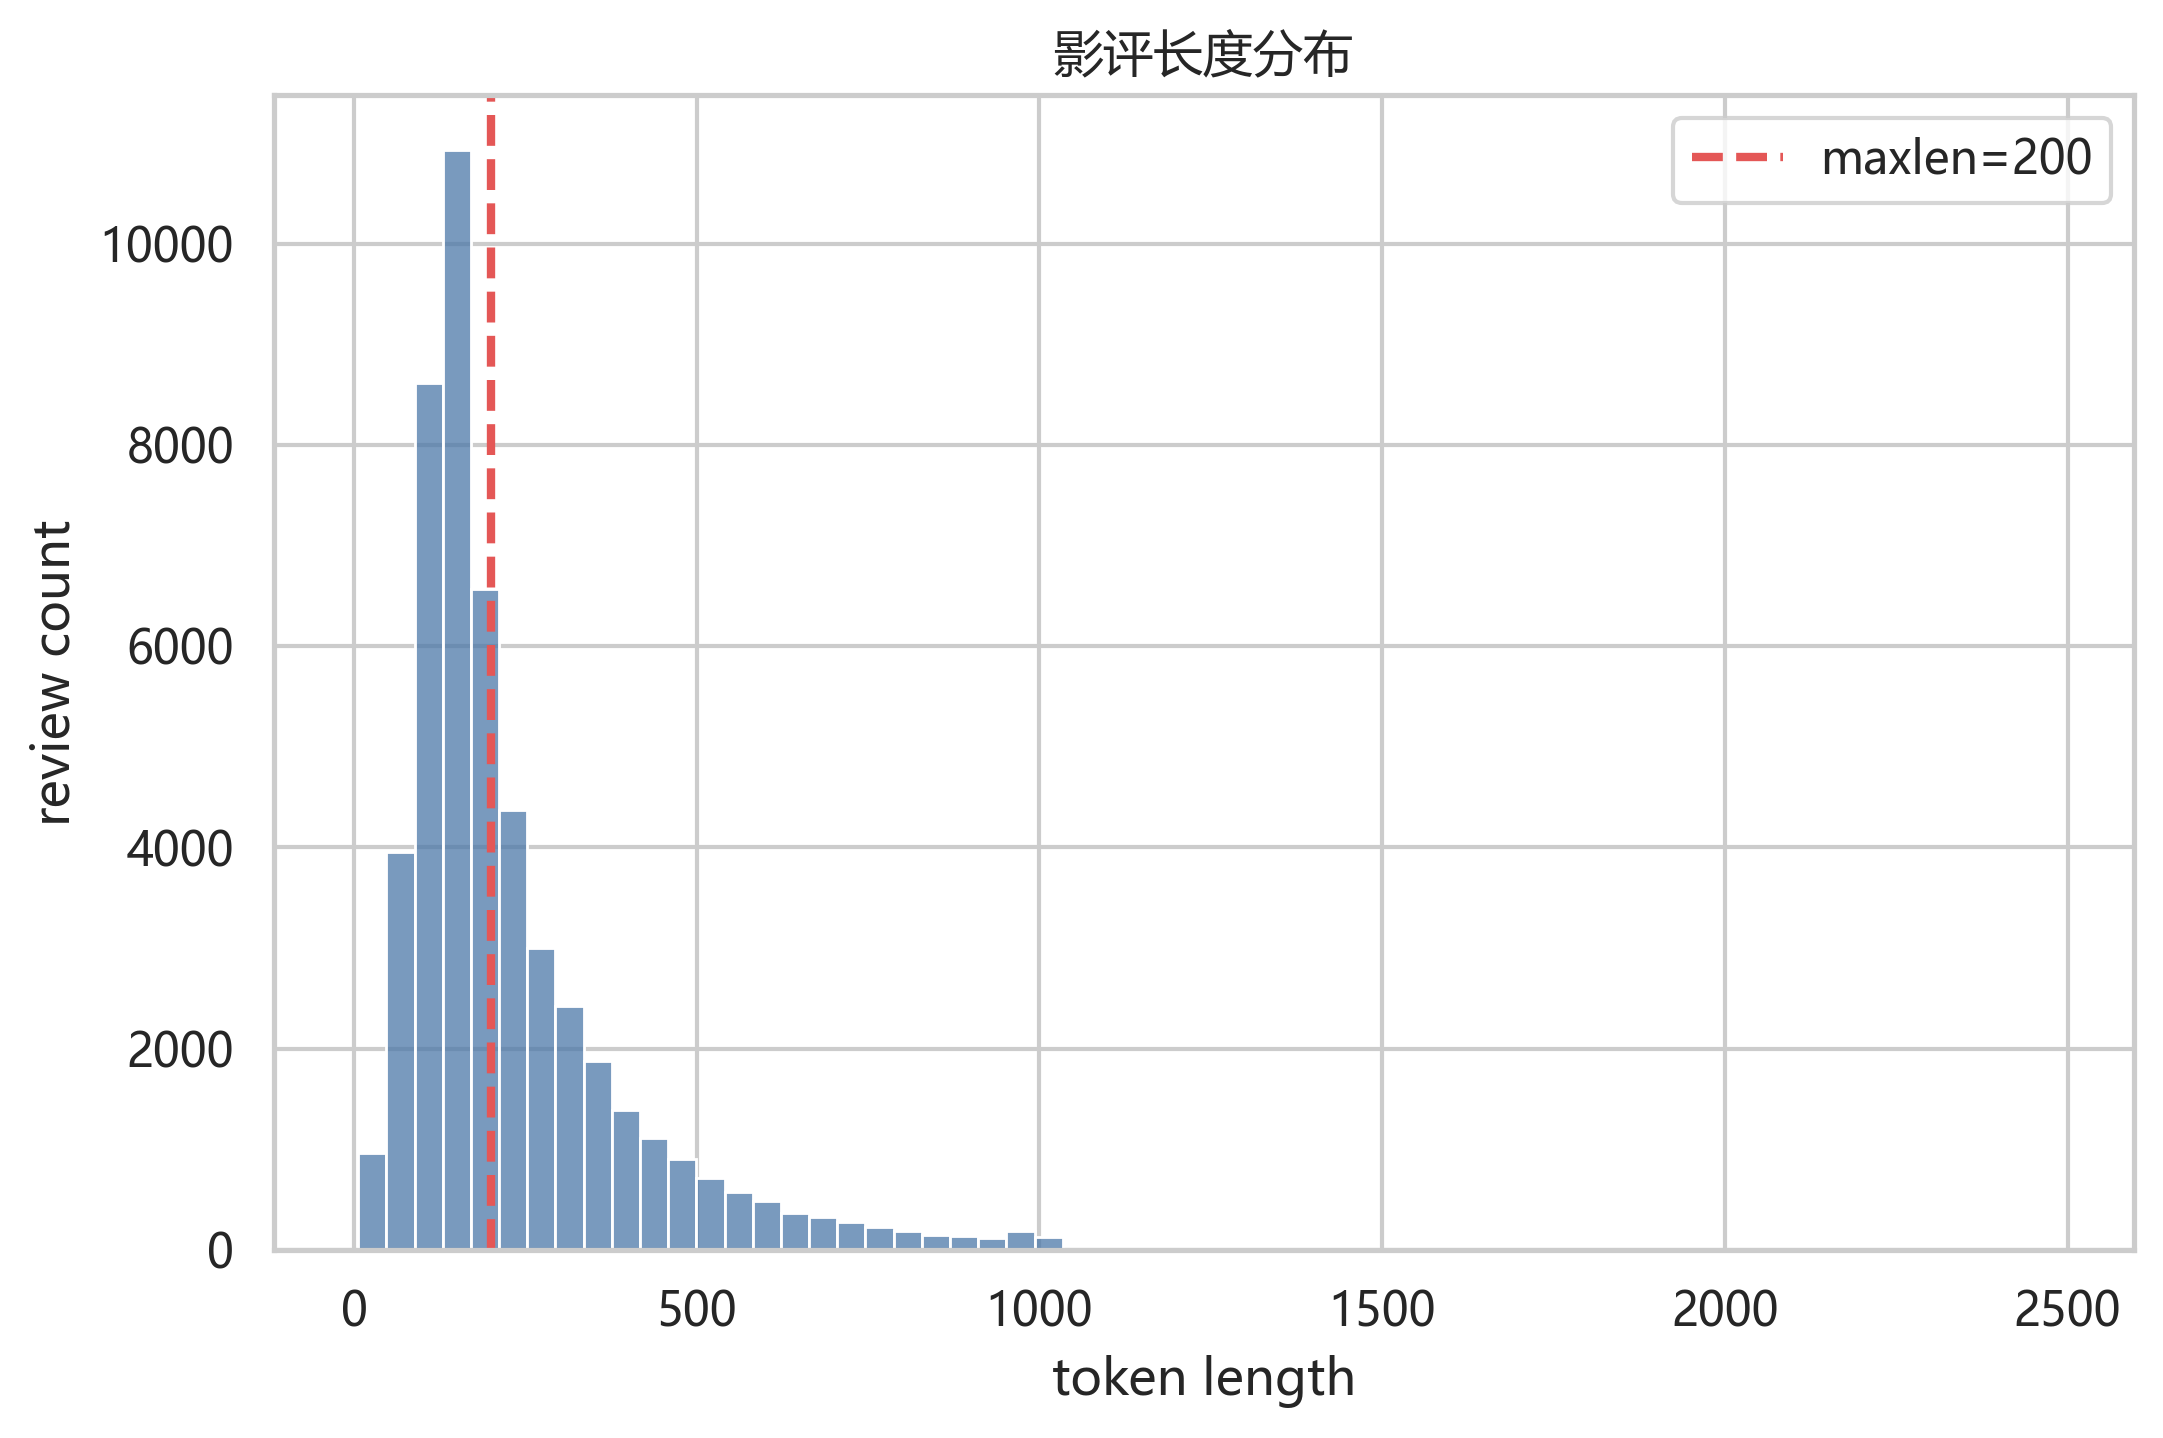

In [6]:
df["clean_review"] = df["review"].apply(clean_text)
df["tokens"] = df["clean_review"].apply(tokenize)
df["review_length"] = df["tokens"].apply(len)

print("平均长度:", round(df["review_length"].mean(), 2))
print("长度中位数:", int(df["review_length"].median()))
print("最大长度:", int(df["review_length"].max()))
print("清洗前:", df.iloc[0]["review"][:220])
print("清洗后:", df.iloc[0]["clean_review"][:220])

plot_length_distribution(df["review_length"], OUTPUT_DIR / "exp5_review_length_distribution.png")
display(Image(filename=str(OUTPUT_DIR / "exp5_review_length_distribution.png")))

## 构建词表与序列化

按照题目要求划分训练集、验证集和测试集。词表只用训练集构建，这样可以避免把验证集和测试集的信息提前泄漏给模型。

In [7]:
train_df, temp_df = train_test_split(
    df, test_size=0.2, random_state=RANDOM_SEED, stratify=df["label"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=RANDOM_SEED, stratify=temp_df["label"]
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

vocab = build_vocab(train_df["tokens"], MAX_VOCAB_SIZE, MIN_WORD_FREQ)
print("train/val/test:", len(train_df), len(val_df), len(test_df))
print("vocab_size:", len(vocab))
print("词表前 20 个词:", list(vocab.keys())[:20])

train/val/test: 40000 5000 5000
vocab_size: 20000
词表前 20 个词: ['<pad>', '<unk>', 'the', 'and', 'a', 'of', 'to', 'is', 'in', 'it', 'i', 'this', 'that', 'was', 'as', 'for', 'with', 'movie', 'but', 'film']


## 构建 DataLoader

把每条评论变成固定长度的数字序列，同时记录真实长度。后面 LSTM 使用 pack_padded_sequence 时会用到真实长度，避免 padding 影响模型。

In [8]:
train_dataset = IMDBReviewDataset(train_df, vocab, MAX_LEN)
val_dataset = IMDBReviewDataset(val_df, vocab, MAX_LEN)
test_dataset = IMDBReviewDataset(test_df, vocab, MAX_LEN)

train_loader = make_loader(train_dataset, shuffle=True)
val_loader = make_loader(val_dataset, shuffle=False)
test_loader = make_loader(test_dataset, shuffle=False)

batch = next(iter(train_loader))
print("input_ids shape:", batch[0].shape)
print("lengths shape:", batch[1].shape)
print("labels shape:", batch[2].shape)

input_ids shape: torch.Size([64, 200])
lengths shape: torch.Size([64])
labels shape: torch.Size([64])


## 搭建 LSTM 模型

模型由 Embedding、LSTM、Dropout 和 Linear 组成。Embedding 把词编号变成词向量，LSTM 负责按顺序读取文本，最后 Linear 输出正类 logit。

In [9]:
model = LSTMSentimentClassifier(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    bidirectional=BIDIRECTIONAL,
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
print(model)

LSTMSentimentClassifier(
  (embedding): Embedding(20000, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)


## 模型训练与 EarlyStopping

训练时每轮记录训练集和验证集的 loss、accuracy。当验证集 loss 连续几轮不再提升时，就提前停止并保留最佳模型。

In [10]:
history, early_info = train_model(model, train_loader, val_loader, criterion, optimizer, device)
print(early_info)


========== Training Logs ==========
Epoch [01/8] | train_loss=0.5754 | val_loss=0.4758 | train_acc=0.6833 | val_acc=0.7710 | time=19.64s
Epoch [02/8] | train_loss=0.4192 | val_loss=0.3570 | train_acc=0.8106 | val_acc=0.8440 | time=26.08s
Epoch [03/8] | train_loss=0.3147 | val_loss=0.3223 | train_acc=0.8665 | val_acc=0.8668 | time=23.98s
Epoch [04/8] | train_loss=0.2631 | val_loss=0.3040 | train_acc=0.8925 | val_acc=0.8774 | time=19.85s
Epoch [05/8] | train_loss=0.2244 | val_loss=0.2931 | train_acc=0.9122 | val_acc=0.8794 | time=21.06s
Epoch [06/8] | train_loss=0.1752 | val_loss=0.3028 | train_acc=0.9329 | val_acc=0.8810 | time=20.78s
Epoch [07/8] | train_loss=0.1431 | val_loss=0.3476 | train_acc=0.9476 | val_acc=0.8788 | time=22.64s
EarlyStopping triggered at epoch 7.
{'best_epoch': 5, 'best_val_loss': 0.2930580770969391, 'patience': 2, 'stopped_early': True, 'trained_epochs': 7}


## 测试集评估

加载验证集 loss 最好的模型，在测试集上计算 Accuracy、Precision、Recall 和 F1，并得到混淆矩阵。

In [11]:
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
y_true, y_prob, y_pred = collect_predictions(model, test_loader, device)

matrix = confusion_matrix(y_true, y_pred, labels=[0, 1])
metrics = {
    "accuracy": accuracy_score(y_true, y_pred),
    "precision": precision_score(y_true, y_pred, zero_division=0),
    "recall": recall_score(y_true, y_pred, zero_division=0),
    "f1": f1_score(y_true, y_pred, zero_division=0),
}
print(matrix)
metrics

[[2158  342]
 [ 324 2176]]


{'accuracy': 0.8668,
 'precision': 0.8641779189833201,
 'recall': 0.8704,
 'f1': 0.867277799920287}

## 结果可视化

把训练曲线、准确率曲线、混淆矩阵和指标柱状图保存到 outputs_exp5 文件夹中，报告里可以直接使用这些图片。

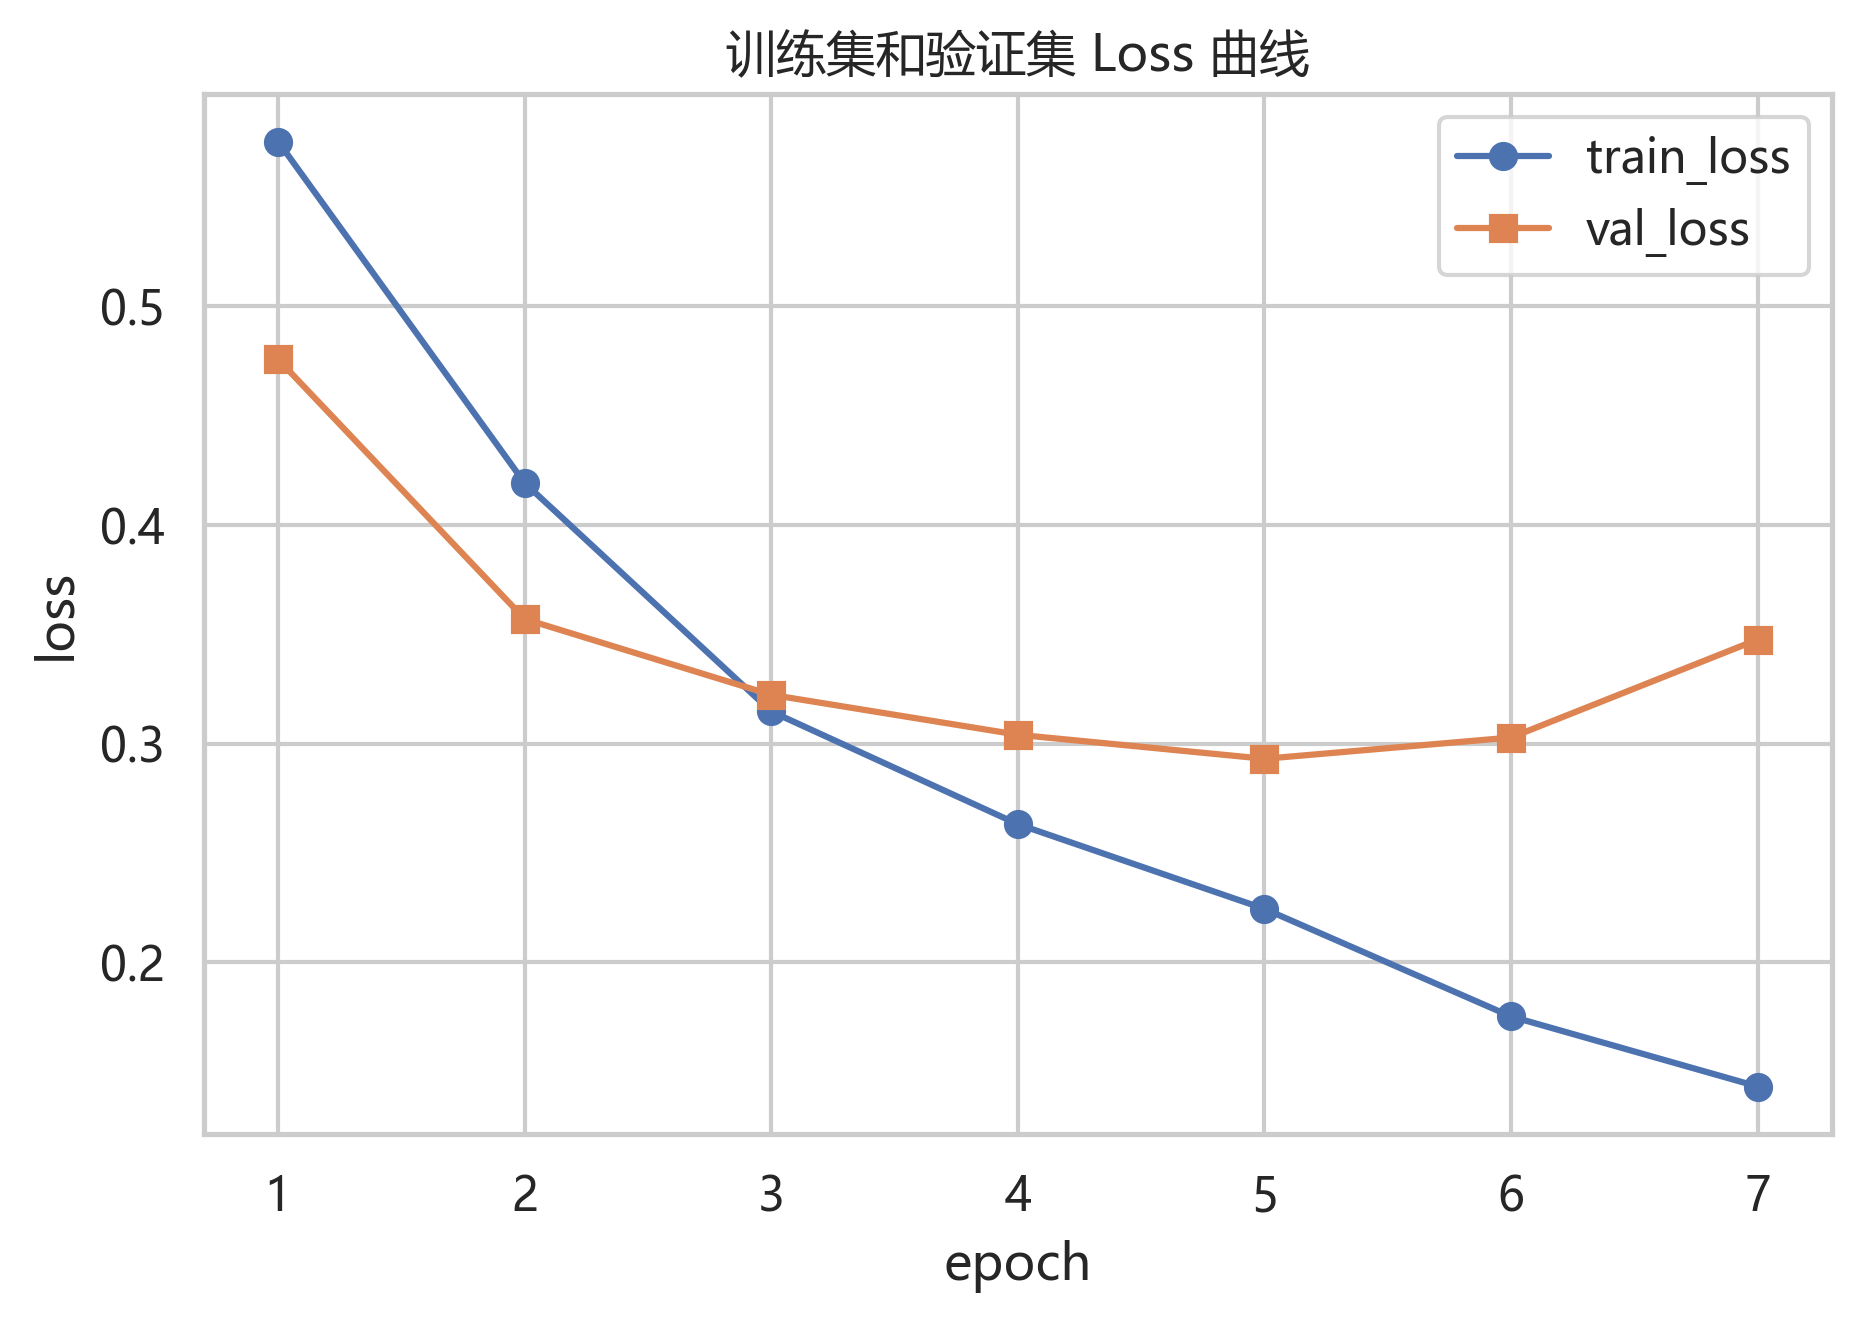

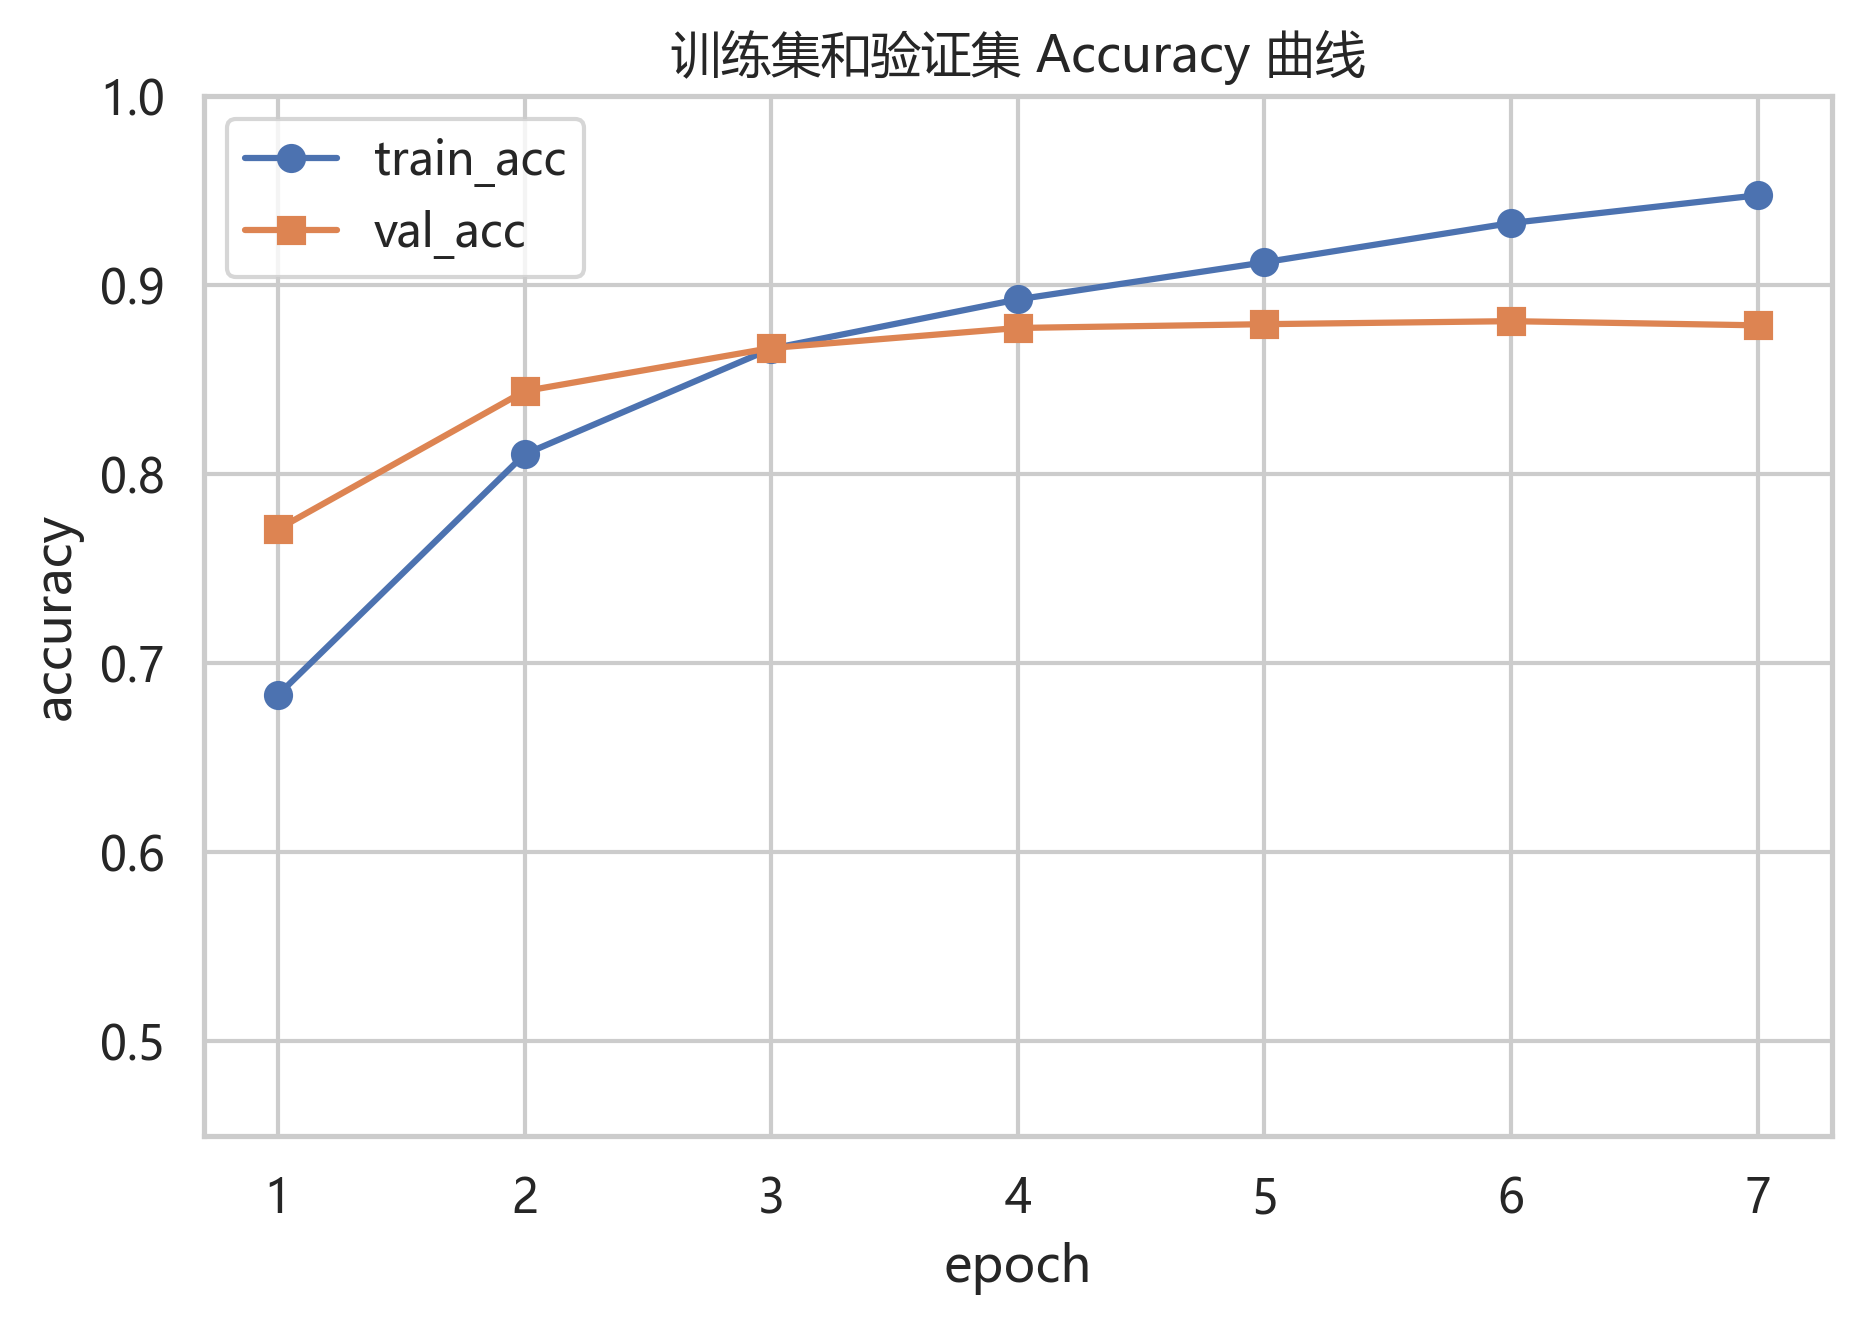

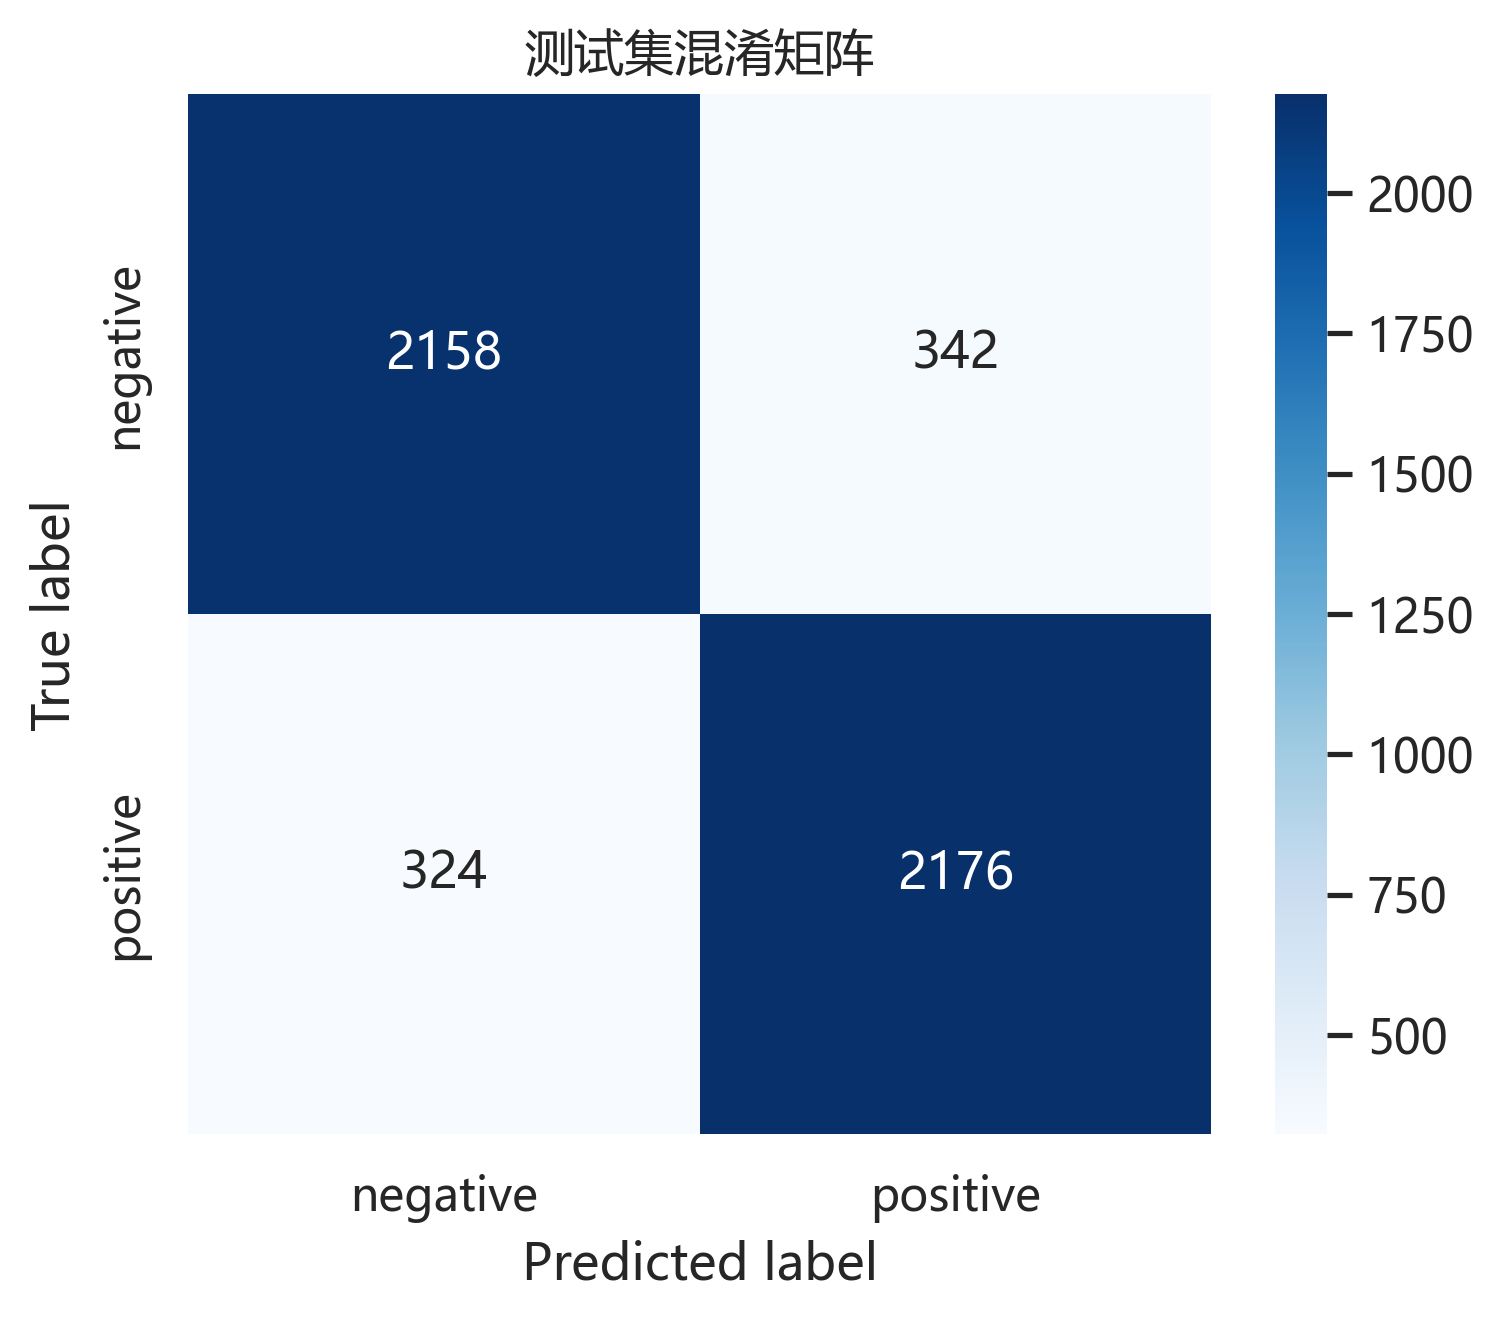

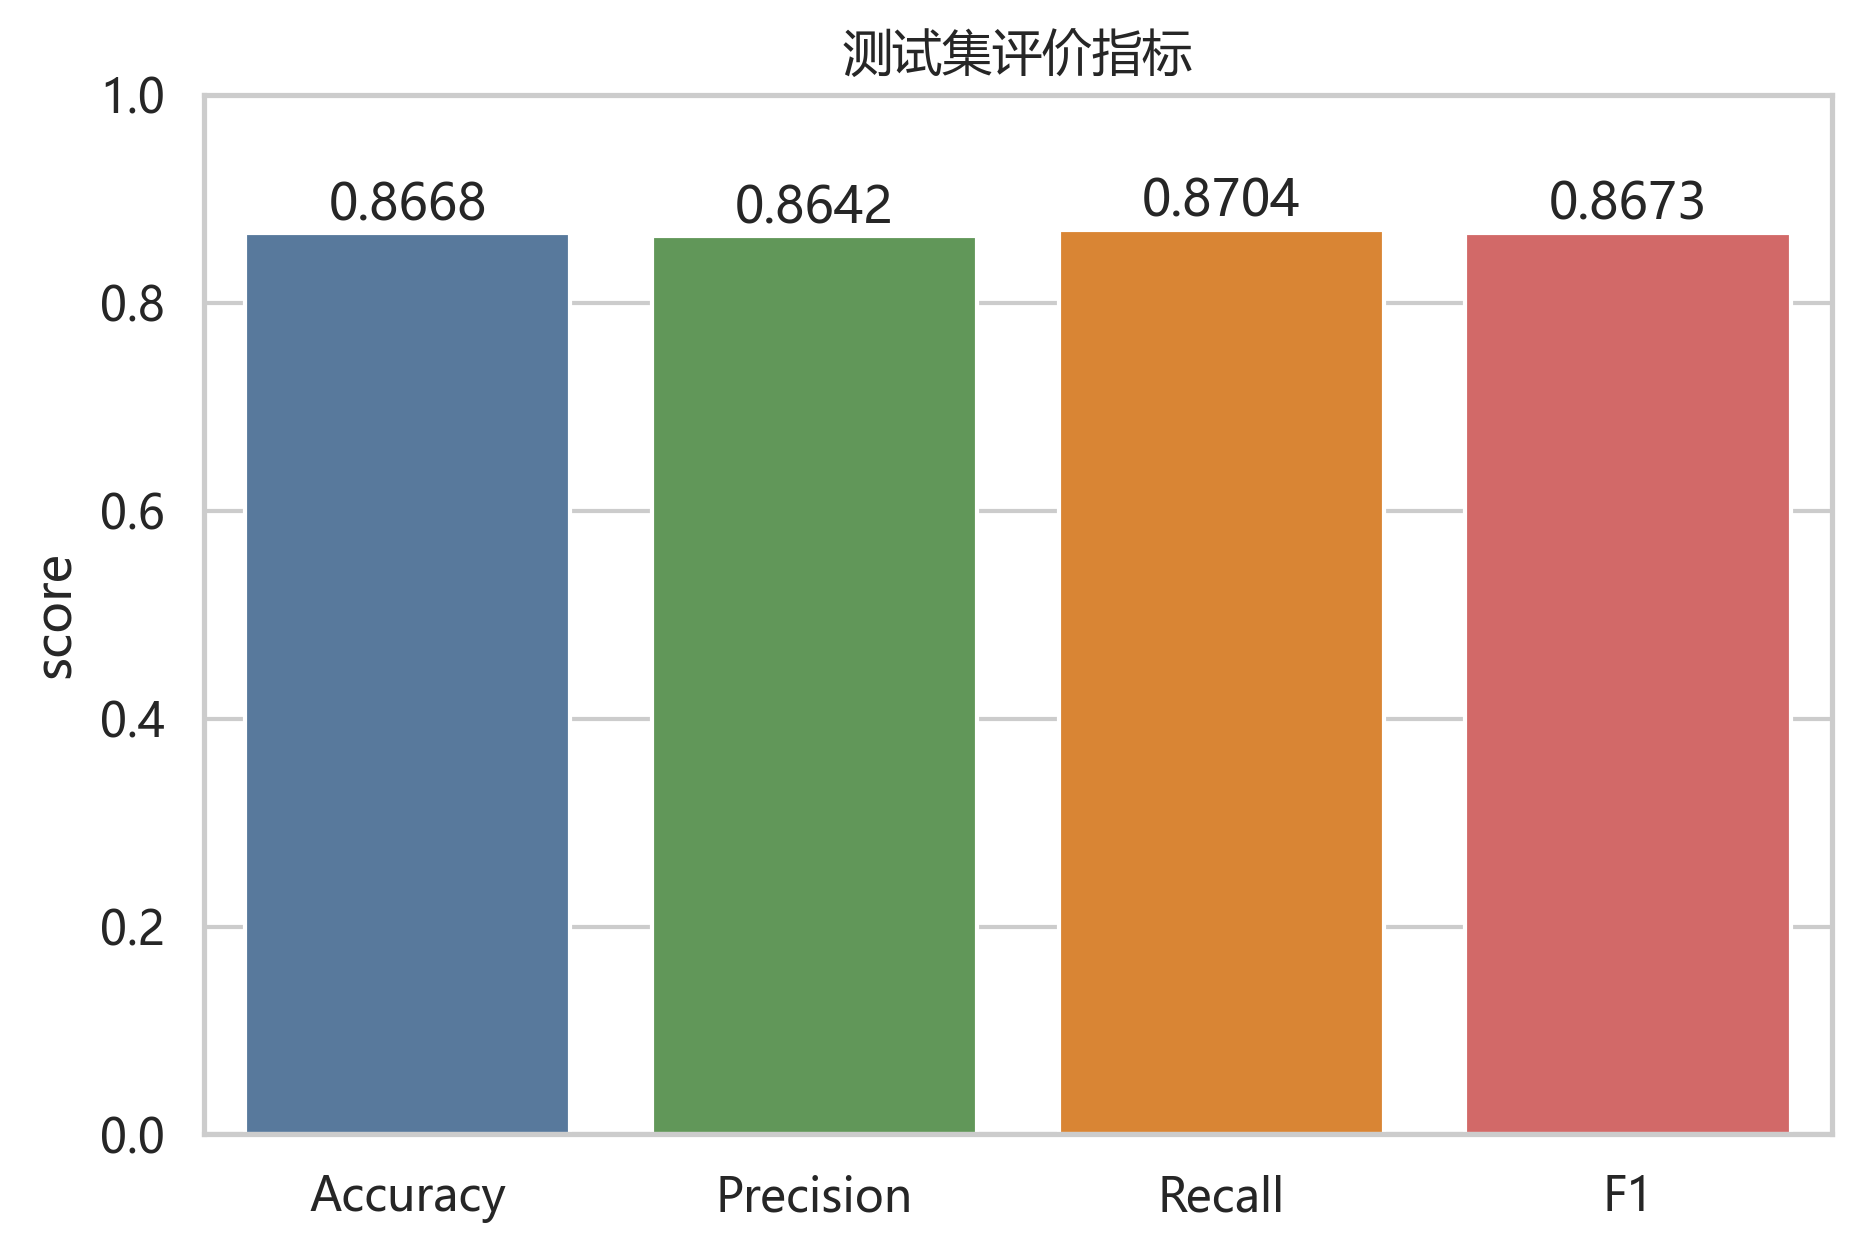

In [12]:
plot_training_loss(history, OUTPUT_DIR / "exp5_training_loss_curve.png")
plot_accuracy_curve(history, OUTPUT_DIR / "exp5_accuracy_curve.png")
plot_confusion_matrix(matrix, OUTPUT_DIR / "exp5_confusion_matrix.png")
plot_metrics_bar(metrics, OUTPUT_DIR / "exp5_metrics_bar.png")

for name in [
    "exp5_training_loss_curve.png",
    "exp5_accuracy_curve.png",
    "exp5_confusion_matrix.png",
    "exp5_metrics_bar.png",
]:
    display(Image(filename=str(OUTPUT_DIR / name)))

## 自定义影评预测

这里输入几句自己写的短评，观察模型给出的情感类别和正类概率。短句结果比较直观，但真实长评论可能有反讽和复杂转折。

In [13]:
sample_reviews = [
    "This movie is fantastic!",
    "A waste of time.",
    "The story is boring and too long.",
    "I really like the actors and the ending is touching.",
    "The film starts slowly, but the ending is powerful and very emotional.",
    "I expected much more from this movie, but it was messy, dull and too long.",
]

sample_predictions = [predict_review(model, review, vocab, device) for review in sample_reviews]
save_prediction_examples(sample_predictions, OUTPUT_DIR / "exp5_prediction_examples.txt")
save_wrong_examples(test_df, y_true, y_prob, y_pred, OUTPUT_DIR / "exp5_wrong_examples.txt")

for item in sample_predictions:
    print(item["review"])
    print("预测:", item["pred_label"], "正类概率:", round(item["prob_positive"], 4))
    print()

This movie is fantastic!
预测: positive 正类概率: 0.9526

A waste of time.
预测: negative 正类概率: 0.0053

The story is boring and too long.
预测: negative 正类概率: 0.0082

I really like the actors and the ending is touching.
预测: positive 正类概率: 0.9686

The film starts slowly, but the ending is powerful and very emotional.
预测: positive 正类概率: 0.992

I expected much more from this movie, but it was messy, dull and too long.
预测: negative 正类概率: 0.0062



## 实验小结

从结果看，LSTM 能够利用影评中词语的先后关系完成 Many-to-One 情感分类。训练后期训练准确率继续上升，但验证集 loss 出现波动，说明 EarlyStopping 对防止过拟合是有必要的。